In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rafsunahmad/apple-stock-price/apple_stock.csv


In [2]:
# ============================================================
# CELL 1 — IMPORTS & LOAD DATA
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

# ── Đọc dữ liệu ──────────────────────────────────────────────
DATA_PATH = '/kaggle/input/datasets/rafsunahmad/apple-stock-price/apple_stock.csv'
df = pd.read_csv(DATA_PATH)

print("=" * 50)
print(f"Shape: {df.shape}")
print("=" * 50)
print(df.head(10))
print("\nColumn dtypes:\n", df.dtypes)

Shape: (2475, 7)
         Date    Open    High     Low   Close  Adj Close     Volume
0  2014-01-02 19.8457 19.8939 19.7150 19.7546    17.3187  234684800
1  2014-01-03 19.7450 19.7750 19.3011 19.3207    16.9383  392467600
2  2014-01-06 19.1946 19.5286 19.0571 19.4261    17.0307  412610800
3  2014-01-07 19.4400 19.4986 19.2114 19.2871    16.9089  317209200
4  2014-01-08 19.2432 19.4843 19.2389 19.4093    17.0160  258529600
5  2014-01-09 19.5286 19.5307 19.1196 19.1614    16.7987  279148800
6  2014-01-10 19.2796 19.3143 18.9682 19.0336    16.6866  304976000
7  2014-01-13 18.9254 19.3750 18.9243 19.1332    16.7739  378492800
8  2014-01-14 19.2221 19.5261 19.2021 19.5139    17.1077  332561600
9  2014-01-15 19.7686 20.0071 19.7021 19.9057    17.4512  391638800

Column dtypes:
 Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [3]:
# ============================================================
# CELL 2 — DATA QUALITY CHECK
# ============================================================
print("━" * 50)
print("📌 MISSING VALUES")
print("━" * 50)
print(df.isnull().sum())

print("\n━" * 50)
print("📌 BASIC STATISTICS")
print("━" * 50)
print(df.describe())

print("\n━" * 50)
print("📌 DUPLICATE ROWS:", df.duplicated().sum())
print("━" * 50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 MISSING VALUES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
📌 BASIC STATISTICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
           Open      High       Low     Close  Adj Close          Volume
count 2475.0000 2475.0000 2475.0000 2475.0000  2475.0000       2475.0000
mean    76.0050   76.8457   75.2137   76.0642    74.0971  138056452.2424
std     54.7391   55.3897   54.1347   54.7876    55.2482   83996735.1935
min     17.6850   17.9118   17.6268   17.8493    15.6483   31458200.0000
25%     29.5925   29.8412   29.3712   29.7075    27.1313   83005000.0000
50%     47.5075   47.9675   47.2675   47.6000    45.5072  113476000.0000
75%    132.1450  133.6800  130.4950  132.0300   130.4033  168213800.0000
max    1

In [4]:
# ============================================================
# CELL 3 — PREPROCESSING: DATE PARSING & CLEANING
# ============================================================

# Tìm cột ngày tháng (tên cột có thể là 'Date', 'date', 'Datetime'...)
date_col = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()]
print("Cột ngày tìm thấy:", date_col)

# Parse và đặt index
df['Date'] = pd.to_datetime(df[date_col[0]])
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)

# Chỉ giữ cột giá đóng cửa để dự đoán
# (Tên cột thường là 'Close' hoặc 'Adj Close')
close_col = [c for c in df.columns if 'close' in c.lower()]
print("Cột giá đóng cửa:", close_col)

df_close = df[[close_col[0]]].copy()
df_close.columns = ['Close']
df_close.dropna(inplace=True)

print(f"\n✅ Dữ liệu sạch — shape: {df_close.shape}")
print(f"   Từ {df_close.index.min().date()} → {df_close.index.max().date()}")
print(df_close.tail())

Cột ngày tìm thấy: ['Date']
Cột giá đóng cửa: ['Close', 'Adj Close']

✅ Dữ liệu sạch — shape: (2475, 1)
   Từ 2014-01-02 → 2023-10-31
              Close
Date               
2023-10-25 171.1000
2023-10-26 166.8900
2023-10-27 168.2200
2023-10-30 170.2900
2023-10-31 170.7700


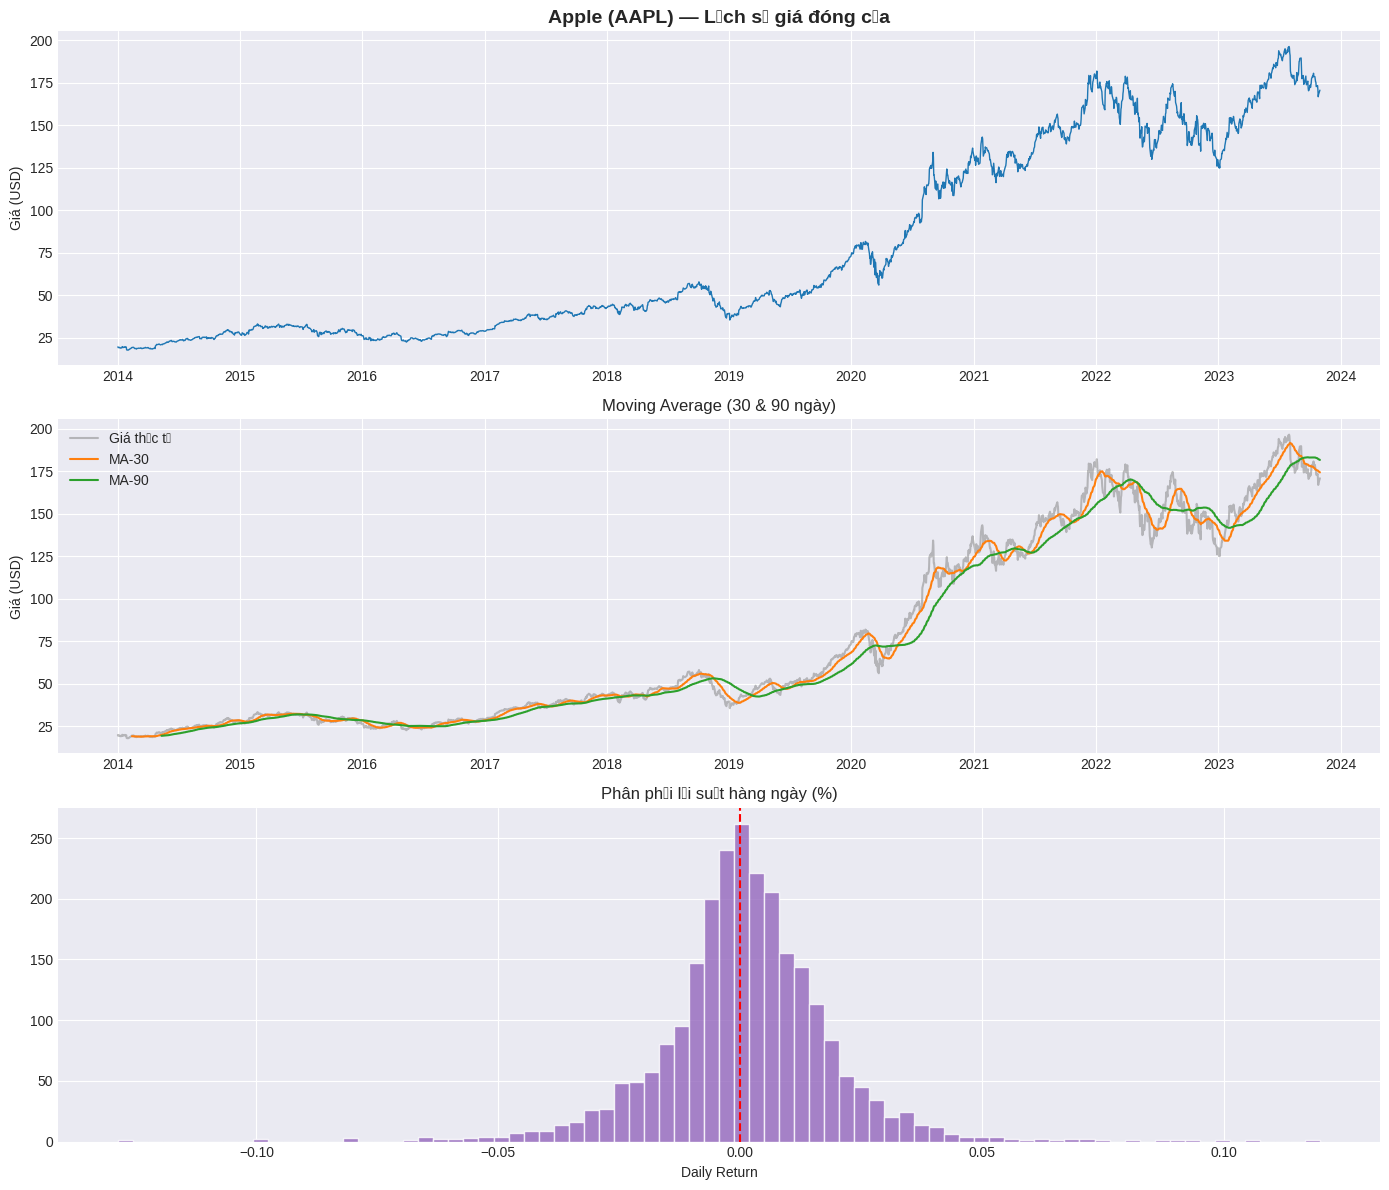

📊 EDA chart saved.


In [5]:
# ============================================================
# CELL 4 — EDA: VISUALIZE PRICE TREND
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Toàn bộ lịch sử giá
axes[0].plot(df_close.index, df_close['Close'], color='#1f77b4', linewidth=1)
axes[0].set_title('Apple (AAPL) — Lịch sử giá đóng cửa', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Giá (USD)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 2: Rolling statistics (xu hướng + biến động)
df_close['MA_30']  = df_close['Close'].rolling(30).mean()
df_close['MA_90']  = df_close['Close'].rolling(90).mean()
df_close['STD_30'] = df_close['Close'].rolling(30).std()

axes[1].plot(df_close.index, df_close['Close'],  color='gray',    alpha=0.5, label='Giá thực tế')
axes[1].plot(df_close.index, df_close['MA_30'],   color='#ff7f0e', linewidth=1.5, label='MA-30')
axes[1].plot(df_close.index, df_close['MA_90'],   color='#2ca02c', linewidth=1.5, label='MA-90')
axes[1].legend()
axes[1].set_title('Moving Average (30 & 90 ngày)', fontsize=12)
axes[1].set_ylabel('Giá (USD)')

# Plot 3: Daily return distribution
df_close['Daily_Return'] = df_close['Close'].pct_change()
axes[2].hist(df_close['Daily_Return'].dropna(), bins=80, color='#9467bd', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Phân phối lợi suất hàng ngày (%)', fontsize=12)
axes[2].set_xlabel('Daily Return')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 EDA chart saved.")

In [27]:
# ============================================================
# CELL 5d — LOG RETURNS APPROACH
# Dự đoán log return thay vì giá tuyệt đối
# log_return[t] = ln(price[t] / price[t-1])
# → Stationary, không bị distribution shift theo năm
# ============================================================
WINDOW_SIZE = 60
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

close_values = df_close['Close'].values.astype(np.float64) 

# ── Bước 1: Tính log returns ─────────────────────────────
log_returns = np.diff(np.log(close_values))
prices_aligned = close_values[1:]

print(f"Log returns — mean: {log_returns.mean():.6f} | "
      f"std: {log_returns.std():.6f} | "
      f"min: {log_returns.min():.4f} | max: {log_returns.max():.4f}")

# ── Bước 2: Scale returns về [-1, 1] ─────────────────────
# Returns đã gần stationary nên scaler sẽ stable hơn nhiều
ret_scaler = MinMaxScaler(feature_range=(-1, 1))
returns_scaled = ret_scaler.fit_transform(log_returns.reshape(-1, 1)).flatten()

# ── Bước 3: Tạo sequences ────────────────────────────────
X_all, y_all = [], []
for i in range(WINDOW_SIZE, len(returns_scaled)):
    X_all.append(returns_scaled[i - WINDOW_SIZE:i].reshape(-1, 1))
    y_all.append(returns_scaled[i])

X_all = np.array(X_all)   # (2414, 60, 1)
y_all = np.array(y_all)   # (2414,)

# Giữ price tại thời điểm t-1 để reconstruct sau
# price[t] = price[t-1] * exp(return[t])
prices_for_reconstruct = prices_aligned[WINDOW_SIZE:]  # price thực tại mỗi t

# ── Bước 4: Temporal split 70/15/15 ─────────────────────
n_seq   = len(X_all)
n_train = int(n_seq * 0.70)
n_val   = int(n_seq * 0.15)

X_train = X_all[:n_train]
y_train = y_all[:n_train]

X_val   = X_all[n_train : n_train + n_val]
y_val   = y_all[n_train : n_train + n_val]

X_test  = X_all[n_train + n_val:]
y_test  = y_all[n_train + n_val:]

# Price t-1 để reconstruct từng tập
# price_prev[i] = giá ngày hôm trước của sample i trong test
price_prev_train = prices_aligned[WINDOW_SIZE - 1 : n_train + WINDOW_SIZE - 1]
price_prev_val   = prices_aligned[n_train + WINDOW_SIZE - 1 :
                                  n_train + n_val + WINDOW_SIZE - 1]
price_prev_test  = prices_aligned[n_train + n_val + WINDOW_SIZE - 1 :
                                  n_train + n_val + WINDOW_SIZE - 1 + len(X_test)]

# ── Kiểm tra ─────────────────────────────────────────────
dates       = df_close.index[1 + WINDOW_SIZE:]
train_dates = dates[:n_train]
val_dates   = dates[n_train : n_train + n_val]
test_dates  = dates[n_train + n_val : n_train + n_val + len(X_test)]

print(f"\n✅ Return-based split:")
print(f"   Train : {X_train.shape} | {train_dates[0].date()} → {train_dates[-1].date()}")
print(f"   Val   : {X_val.shape}   | {val_dates[0].date()} → {val_dates[-1].date()}")
print(f"   Test  : {X_test.shape}  | {test_dates[0].date()} → {test_dates[-1].date()}")
print(f"\n   Returns scaled range: [{returns_scaled.min():.3f}, {returns_scaled.max():.3f}]")
print(f"   y_train range: [{y_train.min():.3f}, {y_train.max():.3f}]")
print(f"   y_val   range: [{y_val.min():.3f}, {y_val.max():.3f}]")
print(f"   y_test  range: [{y_test.min():.3f}, {y_test.max():.3f}]")

Log returns — mean: 0.000872 | std: 0.017997 | min: -0.1377 | max: 0.1132

✅ Return-based split:
   Train : (1689, 60, 1) | 2014-04-01 → 2020-12-11
   Val   : (362, 60, 1)   | 2020-12-14 → 2022-05-20
   Test  : (363, 60, 1)  | 2022-05-23 → 2023-10-31

   Returns scaled range: [-1.000, 1.000]
   y_train range: [-1.000, 1.000]
   y_val   range: [-0.365, 0.636]
   y_test  range: [-0.384, 0.777]


In [28]:
# ============================================================
# CELL 6d — MODEL v4: Output = log return (regression [-1,1])
# ============================================================
def build_cnn_lstm_v4(window_size, n_features=1):
    inputs = Input(shape=(window_size, n_features), name='input')

    # CNN block — kernel_size=5 bắt pattern 1 tuần giao dịch
    x = Conv1D(64, kernel_size=5, padding='causal',
               activation='relu', name='conv1')(inputs)
    x = LayerNormalization(name='ln1')(x)
    x = Dropout(0.2, name='drop1')(x)
    x = MaxPooling1D(pool_size=2, name='pool1')(x)

    x = Conv1D(128, kernel_size=3, padding='causal',
               activation='relu', name='conv2')(x)
    x = LayerNormalization(name='ln2')(x)
    x = Dropout(0.2, name='drop2')(x)
    x = MaxPooling1D(pool_size=2, name='pool2')(x)

    # LSTM block
    x = LSTM(64, return_sequences=True, name='lstm1')(x)
    x = LayerNormalization(name='ln3')(x)
    x = Dropout(0.2, name='drop3')(x)

    x = LSTM(32, return_sequences=False, name='lstm2')(x)
    x = Dropout(0.15, name='drop4')(x)

    # Output: tanh squashes vào (-1, 1) — phù hợp với returns scaled
    x = Dense(16, activation='relu', name='dense1')(x)
    outputs = Dense(1, activation='tanh', name='output')(x)

    model = Model(inputs, outputs, name='CNN_LSTM_v4_returns')
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss='huber',
        metrics=['mae']
    )
    return model

model = build_cnn_lstm_v4(WINDOW_SIZE)
model.summary()
print(f"\nTotal params: {model.count_params():,}")

Model: "CNN_LSTM_v4_returns"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 60, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln1 (LayerNormalization)        │ (None, 60, 64)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 30, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln2 (LayerNormalization)        │ (None, 30, 128)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (None, 15, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln3 (LayerNormalization)        │ (None, 15, 64)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,969 (343.63 KB)

 Trainable params: 87,969 (343.63 KB)

 Non-trainable params: 0 (0.00 B)


Total params: 87,969


In [29]:
# ============================================================
# CELL 9d — TRAINING v4
# ============================================================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=25,
                  restore_best_weights=True, min_delta=1e-6, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=10, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_cnn_lstm_v4.keras', monitor='val_loss',
                    save_best_only=True, verbose=0)
]

history = model.fit(
    X_train, y_train,
    epochs=200, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    shuffle=False, verbose=1
)

best_epoch = np.argmin(history.history['val_loss']) + 1
train_at_best = history.history['loss'][best_epoch - 1]
val_at_best   = history.history['val_loss'][best_epoch - 1]
print(f"\n✅ Best epoch: {best_epoch}")
print(f"   Train loss: {train_at_best:.6f} | Val loss: {val_at_best:.6f}")
print(f"   Gap: {(val_at_best-train_at_best)/train_at_best*100:.1f}%")

Epoch 1/200
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.0148 - mae: 0.1226 - val_loss: 0.0117 - val_mae: 0.1194 - learning_rate: 0.0010
Epoch 2/200
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0113 - mae: 0.1042 - val_loss: 0.0103 - val_mae: 0.1099 - learning_rate: 0.0010
Epoch 3/200
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0109 - mae: 0.1012 - val_loss: 0.0112 - val_mae: 0.1154 - learning_rate: 0.0010
Epoch 4/200
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0108 - mae: 0.1006 - val_loss: 0.0104 - val_mae: 0.1106 - learning_rate: 0.0010
Epoch 5/200
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0109 - mae: 0.1011 - val_loss: 0.0102 - val_mae: 0.1091 - learning_rate: 0.0010
Epoch 6/200
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0107 - mae: 0.0990 - val_loss: 0.0103 - val_mae: 0.1096 - learning_rate: 0.0010
Epoch 7/200
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0106 - mae: 0.0993 - val_loss: 0.0102 - val_mae: 0.1090 - learning_rate: 0.0010
Epoch 

In [30]:
# ============================================================
# CELL 11d — EVALUATION với price reconstruction
# ============================================================
def reconstruct_prices(model, X, y_true_scaled, price_prev, ret_scaler):
    """
    Dự đoán return → inverse scale → exp → nhân price[t-1] = price[t]
    """
    y_ret_scaled = model.predict(X, verbose=0).flatten()

    # Inverse transform returns
    y_ret_pred = ret_scaler.inverse_transform(
                     y_ret_scaled.reshape(-1, 1)).flatten()
    y_ret_true = ret_scaler.inverse_transform(
                     y_true_scaled.reshape(-1, 1)).flatten()

    # Reconstruct prices: price[t] = price[t-1] * exp(log_return[t])
    price_pred = price_prev * np.exp(y_ret_pred)
    price_true = price_prev * np.exp(y_ret_true)

    return price_pred, price_true

p_pred_train, p_true_train = reconstruct_prices(
    model, X_train, y_train, price_prev_train, ret_scaler)
p_pred_val,   p_true_val   = reconstruct_prices(
    model, X_val,   y_val,   price_prev_val,   ret_scaler)
p_pred_test,  p_true_test  = reconstruct_prices(
    model, X_test,  y_test,  price_prev_test,  ret_scaler)

def report(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"\n  {'─'*40}")
    print(f"  📌 {label}")
    print(f"  {'─'*40}")
    print(f"  RMSE : ${rmse:>8.4f}")
    print(f"  MAE  : ${mae:>8.4f}")
    print(f"  MAPE :  {mape:>8.4f}%")
    print(f"  R²   :  {r2:>8.4f}")
    return dict(rmse=rmse, mae=mae, mape=mape, r2=r2)

print("=" * 44)
print("   📊 KẾT QUẢ CNN-LSTM v4 (Returns)")
print("=" * 44)
report(p_true_train, p_pred_train, 'TRAIN SET')
report(p_true_val,   p_pred_val,   'VALIDATION SET')
m = report(p_true_test,  p_pred_test,  'TEST SET')

naive_mae  = mean_absolute_error(p_true_test[1:], p_true_test[:-1])
naive_mape = np.mean(np.abs(np.diff(p_true_test) / p_true_test[:-1])) * 100
print(f"\n  {'─'*40}")
print(f"  📏 NAIVE BASELINE")
print(f"  {'─'*40}")
print(f"  MAE  : ${naive_mae:.4f} | MAPE: {naive_mape:.4f}%")
print(f"\n  {'✅ Vượt baseline!' if m['mae'] < naive_mae else '⚠️  Chưa vượt'}")
print(f"  MAE  delta: {(naive_mae-m['mae'])/naive_mae*100:+.1f}%")
print(f"  MAPE delta: {(naive_mape-m['mape'])/naive_mape*100:+.1f}%")

   📊 KẾT QUẢ CNN-LSTM v4 (Returns)

  ────────────────────────────────────────
  📌 TRAIN SET
  ────────────────────────────────────────
  RMSE : $  0.9815
  MAE  : $  0.5506
  MAPE :    1.1284%
  R²   :    0.9983

  ────────────────────────────────────────
  📌 VALIDATION SET
  ────────────────────────────────────────
  RMSE : $  2.6073
  MAE  : $  1.9735
  MAPE :    1.3408%
  R²   :    0.9771

  ────────────────────────────────────────
  📌 TEST SET
  ────────────────────────────────────────
  RMSE : $  2.8236
  MAE  : $  2.1420
  MAPE :    1.3804%
  R²   :    0.9746

  ────────────────────────────────────────
  📏 NAIVE BASELINE
  ────────────────────────────────────────
  MAE  : $2.0603 | MAPE: 1.3247%

  ⚠️  Chưa vượt
  MAE  delta: -4.0%
  MAPE delta: -4.2%


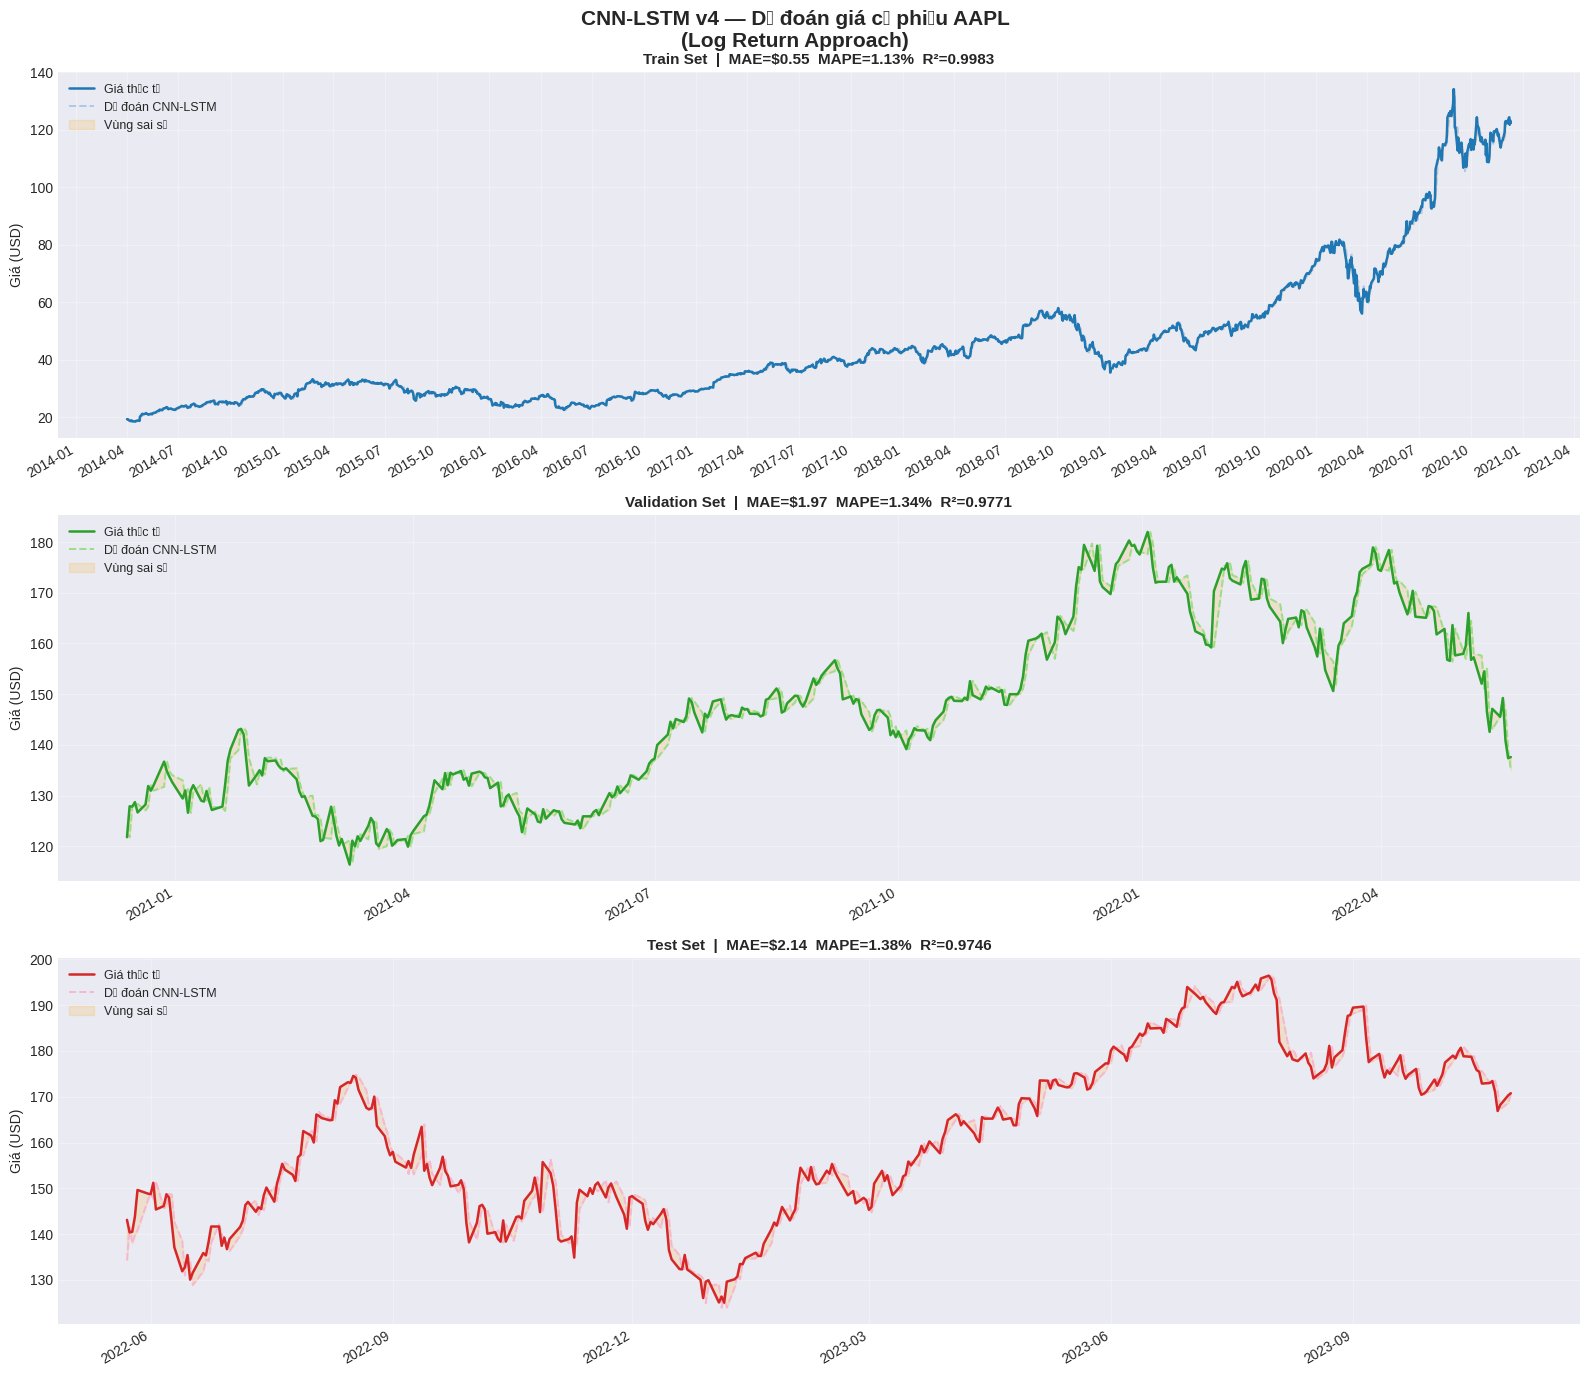

✅ Saved: prediction_vs_actual.png


In [31]:
# ============================================================
# CELL 12 — MAIN VISUALIZATION: PREDICTED vs ACTUAL
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('CNN-LSTM v4 — Dự đoán giá cổ phiếu AAPL\n(Log Return Approach)',
             fontsize=15, fontweight='bold', y=0.98)

datasets = [
    (train_dates, p_true_train, p_pred_train, 'Train Set',      '#1f77b4', '#aec7e8'),
    (val_dates,   p_true_val,   p_pred_val,   'Validation Set', '#2ca02c', '#98df8a'),
    (test_dates,  p_true_test,  p_pred_test,  'Test Set',       '#d62728', '#f7b6d2'),
]

for ax, (dates, y_true, y_pred, title, c1, c2) in zip(axes, datasets):
    ax.plot(dates, y_true, color=c1, linewidth=1.8,
            label='Giá thực tế', zorder=3)
    ax.plot(dates, y_pred, color=c2, linewidth=1.4,
            linestyle='--', label='Dự đoán CNN-LSTM', zorder=2)

    # Vùng sai số
    ax.fill_between(dates, y_true, y_pred,
                    alpha=0.15, color='orange', label='Vùng sai số')

    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)

    ax.set_title(f'{title}  |  MAE=${mae:.2f}  MAPE={mape:.2f}%  R²={r2:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Giá (USD)')
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: prediction_vs_actual.png")

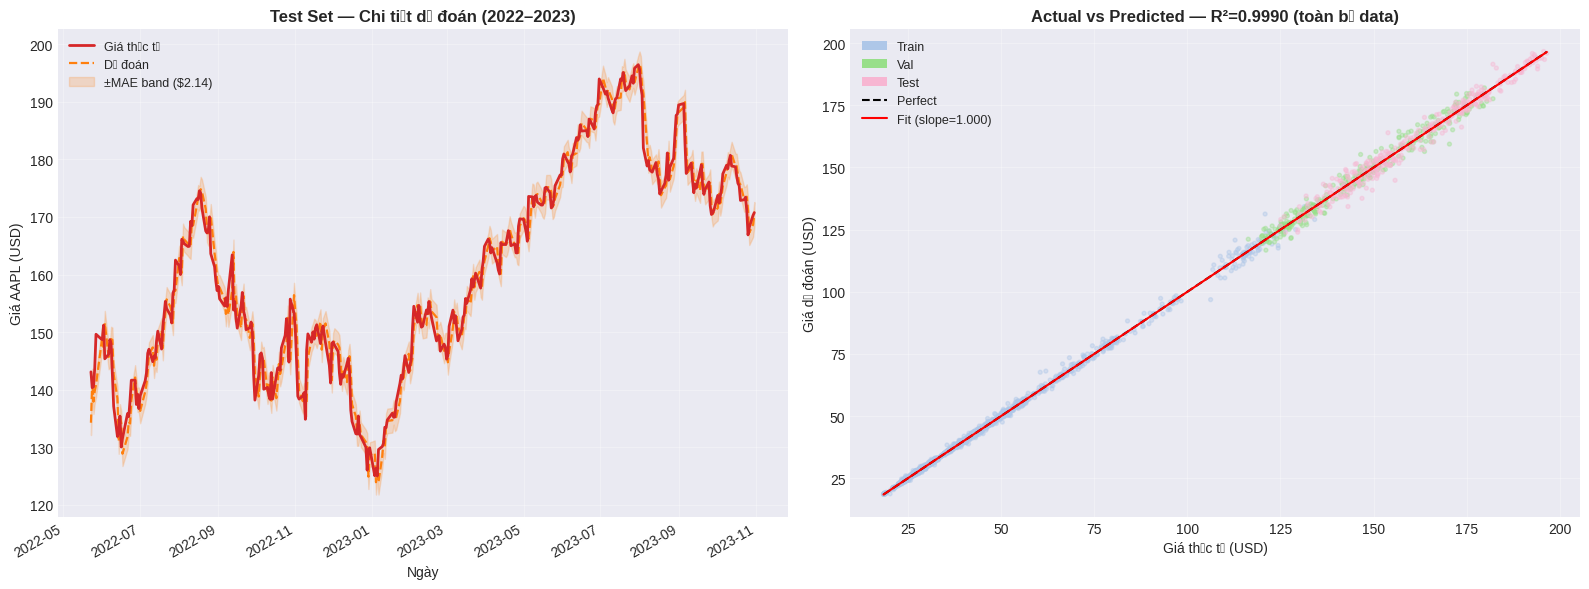

✅ Saved: test_zoom_scatter.png


In [32]:
# ============================================================
# CELL 13 — TEST SET DEEP DIVE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Test Set zoom với confidence band ─────────────
ax = axes[0]
errors = np.abs(p_pred_test - p_true_test)
mae_test = errors.mean()

ax.plot(test_dates, p_true_test, color='#d62728',
        linewidth=2, label='Giá thực tế', zorder=4)
ax.plot(test_dates, p_pred_test, color='#ff7f0e',
        linewidth=1.6, linestyle='--', label='Dự đoán', zorder=3)
ax.fill_between(test_dates,
                p_pred_test - mae_test,
                p_pred_test + mae_test,
                alpha=0.2, color='#ff7f0e', label=f'±MAE band (${mae_test:.2f})')

ax.set_title('Test Set — Chi tiết dự đoán (2022–2023)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Giá AAPL (USD)')
ax.set_xlabel('Ngày')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.grid(True, alpha=0.3)

# ── Plot 2: Scatter — Actual vs Predicted ────────────────
ax = axes[1]
all_true = np.concatenate([p_true_train, p_true_val, p_true_test])
all_pred = np.concatenate([p_pred_train, p_pred_val, p_pred_test])
colors_scatter = (
    ['#aec7e8'] * len(p_true_train) +
    ['#98df8a'] * len(p_true_val)   +
    ['#f7b6d2'] * len(p_true_test)
)

ax.scatter(all_true, all_pred, c=colors_scatter,
           alpha=0.4, s=8, zorder=2)

# Đường perfect prediction
mn, mx = all_true.min(), all_true.max()
ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5,
        label='Perfect prediction', zorder=3)

# Regression line
z = np.polyfit(all_true, all_pred, 1)
p_line = np.poly1d(z)
x_line = np.linspace(mn, mx, 200)
ax.plot(x_line, p_line(x_line), 'red', linewidth=1.5,
        label=f'Trend (slope={z[0]:.3f})', zorder=4)

# Legend proxy
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#aec7e8', label='Train'),
    Patch(facecolor='#98df8a', label='Val'),
    Patch(facecolor='#f7b6d2', label='Test'),
]
ax.legend(handles=legend_elements + [
    plt.Line2D([0],[0], color='black', linestyle='--', label='Perfect'),
    plt.Line2D([0],[0], color='red',   label=f'Fit (slope={z[0]:.3f})')
], fontsize=9)

r2_all = r2_score(all_true, all_pred)
ax.set_title(f'Actual vs Predicted — R²={r2_all:.4f} (toàn bộ data)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Giá thực tế (USD)')
ax.set_ylabel('Giá dự đoán (USD)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('test_zoom_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: test_zoom_scatter.png")

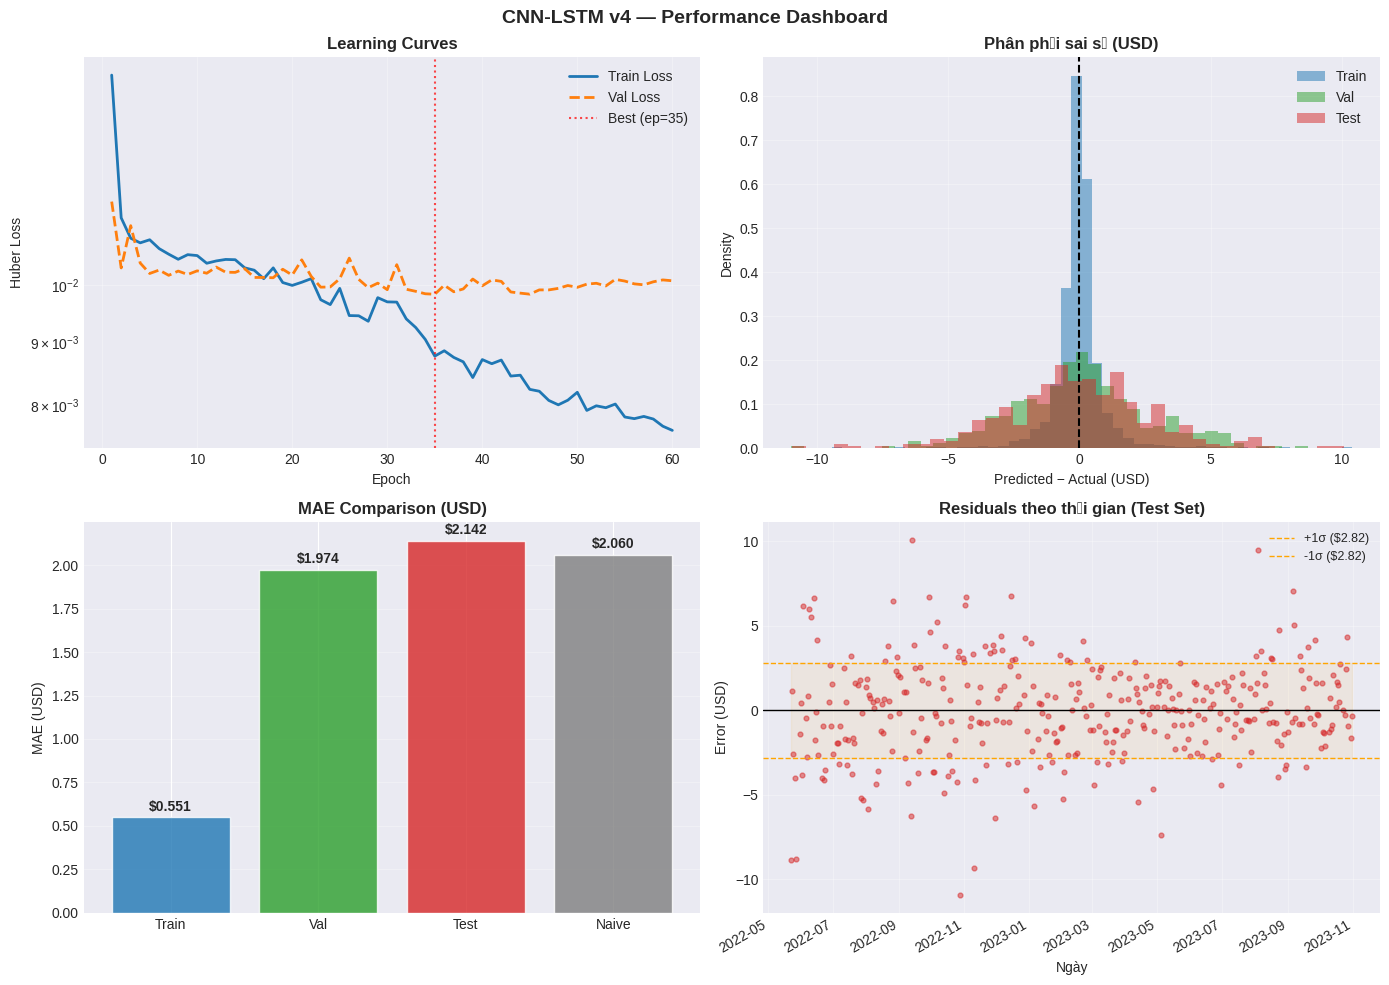

✅ Saved: metrics_dashboard.png


In [33]:
# ============================================================
# CELL 14 — METRICS DASHBOARD
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CNN-LSTM v4 — Performance Dashboard',
             fontsize=14, fontweight='bold')

# ── 1. Learning curves ────────────────────────────────────
ax = axes[0, 0]
ep = range(1, len(history.history['loss']) + 1)
ax.plot(ep, history.history['loss'],     label='Train Loss', color='#1f77b4', lw=2)
ax.plot(ep, history.history['val_loss'], label='Val Loss',   color='#ff7f0e',
        lw=2, linestyle='--')
ax.axvline(best_epoch, color='red', linestyle=':', alpha=0.7,
           label=f'Best (ep={best_epoch})')
ax.set_title('Learning Curves', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
ax.legend(); ax.set_yscale('log'); ax.grid(True, alpha=0.3)

# ── 2. Error distribution ─────────────────────────────────
ax = axes[0, 1]
err_train = p_pred_train - p_true_train
err_val   = p_pred_val   - p_true_val
err_test  = p_pred_test  - p_true_test

ax.hist(err_train, bins=50, alpha=0.5, color='#1f77b4', label='Train', density=True)
ax.hist(err_val,   bins=40, alpha=0.5, color='#2ca02c', label='Val',   density=True)
ax.hist(err_test,  bins=40, alpha=0.5, color='#d62728', label='Test',  density=True)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_title('Phân phối sai số (USD)', fontweight='bold')
ax.set_xlabel('Predicted − Actual (USD)'); ax.set_ylabel('Density')
ax.legend(); ax.grid(True, alpha=0.3)

# ── 3. Metrics comparison bar chart ───────────────────────
ax = axes[1, 0]
labels  = ['Train', 'Val', 'Test', 'Naive']
mae_vals  = [
    mean_absolute_error(p_true_train, p_pred_train),
    mean_absolute_error(p_true_val,   p_pred_val),
    mean_absolute_error(p_true_test,  p_pred_test),
    naive_mae
]
colors_bar = ['#1f77b4', '#2ca02c', '#d62728', '#7f7f7f']
bars = ax.bar(labels, mae_vals, color=colors_bar, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'${val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('MAE Comparison (USD)', fontweight='bold')
ax.set_ylabel('MAE (USD)'); ax.grid(True, alpha=0.3, axis='y')

# ── 4. Residuals over time (test set) ─────────────────────
ax = axes[1, 1]
ax.scatter(test_dates, err_test, alpha=0.5, s=12, color='#d62728', zorder=2)
ax.axhline(0,                  color='black', linestyle='-',  linewidth=1)
ax.axhline( err_test.std(),    color='orange', linestyle='--', linewidth=1,
            label=f'+1σ (${err_test.std():.2f})')
ax.axhline(-err_test.std(),    color='orange', linestyle='--', linewidth=1,
            label=f'-1σ (${err_test.std():.2f})')
ax.fill_between(test_dates, -err_test.std(), err_test.std(),
                alpha=0.08, color='orange')
ax.set_title('Residuals theo thời gian (Test Set)', fontweight='bold')
ax.set_xlabel('Ngày'); ax.set_ylabel('Error (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: metrics_dashboard.png")

# Đóng gói dự án

In [34]:
# ============================================================
# CELL 15 — SAVE ALL ARTIFACTS
# ============================================================
import joblib, json, os
from datetime import datetime

SAVE_DIR = '/kaggle/working/aapl_predictor'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Model weights
model.save(f'{SAVE_DIR}/cnn_lstm_v4.keras')

# 2. Scaler
joblib.dump(ret_scaler, f'{SAVE_DIR}/ret_scaler.pkl')

# 3. Metadata — mọi thứ cần để reproduce
metadata = {
    'model_version'  : 'CNN_LSTM_v4_returns',
    'trained_at'     : datetime.now().strftime('%Y-%m-%d %H:%M'),
    'window_size'    : int(WINDOW_SIZE),
    'train_period'   : [str(train_dates[0].date()), str(train_dates[-1].date())],
    'test_period'    : [str(test_dates[0].date()),  str(test_dates[-1].date())],
    'metrics_test'   : {
        'rmse' : round(float(np.sqrt(mean_squared_error(p_true_test, p_pred_test))), 4),
        'mae'  : round(float(mean_absolute_error(p_true_test, p_pred_test)), 4),
        'mape' : round(float(np.mean(np.abs((p_true_test-p_pred_test)/p_true_test))*100), 4),
        'r2'   : round(float(r2_score(p_true_test, p_pred_test)), 4),
    },
    'feature'        : 'log_return_of_close_price',
    'scaler_range'   : [-1, 1],
}
with open(f'{SAVE_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# 4. Lưu last 60 ngày giá thực (seed cho inference mới)
last_window_prices = close_values[-(WINDOW_SIZE + 1):]
np.save(f'{SAVE_DIR}/last_window_prices.npy', last_window_prices)

print("✅ Artifacts saved:")
for fname in os.listdir(SAVE_DIR):
    size = os.path.getsize(f'{SAVE_DIR}/{fname}')
    print(f"   {fname:<35} {size/1024:>8.1f} KB")

print(f"\nMetadata preview:")
print(json.dumps(metadata, indent=2))

✅ Artifacts saved:
   last_window_prices.npy                   0.6 KB
   cnn_lstm_v4.keras                     1110.6 KB
   metadata.json                            0.4 KB
   ret_scaler.pkl                           0.7 KB

Metadata preview:
{
  "model_version": "CNN_LSTM_v4_returns",
  "trained_at": "2026-06-11 04:16",
  "window_size": 60,
  "train_period": [
    "2014-04-01",
    "2020-12-11"
  ],
  "test_period": [
    "2022-05-23",
    "2023-10-31"
  ],
  "metrics_test": {
    "rmse": 2.8236,
    "mae": 2.142,
    "mape": 1.3804,
    "r2": 0.9746
  },
  "feature": "log_return_of_close_price",
  "scaler_range": [
    -1,
    1
  ]
}


In [37]:
# ============================================================
# CELL 16 — PRODUCTION PREDICTOR CLASS
# ============================================================
import tensorflow as tf
import numpy as np
import joblib, json
from tensorflow.keras.models import load_model

class AAPLPredictor:
    """
    End-to-end predictor cho giá cổ phiếu AAPL.

    Workflow:
        prices (USD) → log returns → scale → model → unscale → reconstruct price

    Usage:
        predictor = AAPLPredictor.load('/kaggle/working/aapl_predictor')
        result = predictor.predict_next(recent_prices)
        result = predictor.predict_n_days(recent_prices, n=5)
    """

    def __init__(self, model, ret_scaler, metadata, window_size=60):
        self.model       = model
        self.ret_scaler  = ret_scaler
        self.metadata    = metadata
        self.window_size = window_size

    # ── Khởi tạo từ file đã lưu ──────────────────────────
    @classmethod
    def load(cls, save_dir: str):
        model      = load_model(f'{save_dir}/cnn_lstm_v4.keras')
        ret_scaler = joblib.load(f'{save_dir}/ret_scaler.pkl')
        with open(f'{save_dir}/metadata.json') as f:
            metadata = json.load(f)
        print(f"✅ Loaded model: {metadata['model_version']}")
        print(f"   Trained on  : {metadata['train_period']}")
        print(f"   Test MAPE   : {metadata['metrics_test']['mape']}%")
        return cls(model, ret_scaler, metadata, metadata['window_size'])

    # ── Validate input ────────────────────────────────────
    def _validate(self, prices: np.ndarray):
        prices = np.array(prices, dtype=np.float64).flatten()
        needed = self.window_size + 1   # +1 để tính return đầu tiên
        if len(prices) < needed:
            raise ValueError(
                f"Cần ít nhất {needed} ngày giá lịch sử, "
                f"chỉ có {len(prices)}."
            )
        return prices[-(needed):]       # lấy đúng window cần thiết

    # ── Core: prices → model input tensor ────────────────
    def _prepare_input(self, prices: np.ndarray) -> np.ndarray:
        """
        prices: array shape (window_size+1,) — giá USD
        returns: X shape (1, window_size, 1) — scaled log returns
        """
        log_rets = np.diff(np.log(prices))            # (window_size,)
        scaled   = self.ret_scaler.transform(
                       log_rets.reshape(-1, 1)).flatten()
        return scaled.reshape(1, self.window_size, 1) # (1, 60, 1)

    # ── Dự đoán 1 ngày tiếp theo ─────────────────────────
    def predict_next(self, recent_prices: np.ndarray) -> dict:
        """
        Args:
            recent_prices: ít nhất 61 ngày giá đóng cửa gần nhất (USD)

        Returns:
            dict với predicted_price, expected_return_pct, confidence_band
        """
        prices  = self._validate(recent_prices)
        X       = self._prepare_input(prices)
        last_price = prices[-1]

        ret_scaled_pred = self.model.predict(X, verbose=0)[0, 0]
        ret_pred = self.ret_scaler.inverse_transform(
                       [[ret_scaled_pred]])[0, 0]

        predicted_price = last_price * np.exp(ret_pred)
        ret_pct         = (predicted_price / last_price - 1) * 100

        # Confidence band dựa trên MAE test
        mae = self.metadata['metrics_test']['mae']

        return {
            'last_known_price'   : round(last_price, 2),
            'predicted_price'    : round(predicted_price, 2),
            'expected_return_pct': round(ret_pct, 4),
            'direction'          : '📈 Tăng' if ret_pct > 0 else '📉 Giảm',
            'confidence_band'    : {
                'lower': round(predicted_price - mae, 2),
                'upper': round(predicted_price + mae, 2),
            },
            'mae_usd'            : mae,
        }

    # ── Dự đoán N ngày liên tiếp (multi-step) ────────────
    def predict_n_days(self, recent_prices: np.ndarray, n: int = 5) -> list:
        """
        Auto-regressive: dự đoán ngày t+1, dùng làm input cho t+2, ...

        ⚠️  Lưu ý: sai số tích lũy theo n. Chỉ tin cậy với n ≤ 5.
        """
        prices = list(self._validate(recent_prices))
        results = []

        for day in range(1, n + 1):
            window  = np.array(prices[-(self.window_size + 1):])
            result  = self.predict_next(window)
            results.append({
                'day'            : day,
                'predicted_price': result['predicted_price'],
                'return_pct'     : result['expected_return_pct'],
                'direction'      : result['direction'],
                'band_lower'     : result['confidence_band']['lower'],
                'band_upper'     : result['confidence_band']['upper'],
            })
            # Dùng predicted price làm input cho bước tiếp theo
            prices.append(result['predicted_price'])

        return results

    def summary(self):
        m = self.metadata
        print(f"{'='*45}")
        print(f"  Model   : {m['model_version']}")
        print(f"  Feature : {m['feature']}")
        print(f"  Window  : {m['window_size']} ngày")
        print(f"  ── Test Metrics ──────────────────────")
        for k, v in m['metrics_test'].items():
            unit = '%' if k in ['mape'] else ('  ' if k == 'r2' else ' USD')
            print(f"  {k.upper():<6}: {v}{unit}")
        print(f"{'='*45}")

✅ Loaded model: CNN_LSTM_v4_returns
   Trained on  : ['2014-04-01', '2020-12-11']
   Test MAPE   : 1.3804%
  Model   : CNN_LSTM_v4_returns
  Feature : log_return_of_close_price
  Window  : 60 ngày
  ── Test Metrics ──────────────────────
  RMSE  : 2.8236 USD
  MAE   : 2.142 USD
  MAPE  : 1.3804%
  R2    : 0.9746  

  🔮 DỰ ĐOÁN 1 NGÀY TIẾP THEO
  last_known_price      : 170.77
  predicted_price       : 171.07
  expected_return_pct   : 0.1747
  direction             : 📈 Tăng
  confidence_band       : {'lower': np.float64(168.93), 'upper': np.float64(173.21)}
  mae_usd               : 2.142

  📅 DỰ ĐOÁN 5 NGÀY TIẾP THEO
  (Sau ngày 2023-10-31)
  Ngày    Giá dự đoán    Return   Hướng                  Band
  ────────────────────────────────────────────────────────────
  t+1    $     171.07  +0.1747%  📈 Tăng  [168.93 – 173.21]
  t+2    $     171.02  -0.0319%  📉 Giảm  [168.87 – 173.16]
  t+3    $     171.69  +0.3946%  📈 Tăng  [169.55 – 173.84]
  t+4    $     171.52  -0.0996%  📉 Giảm  [169.38 

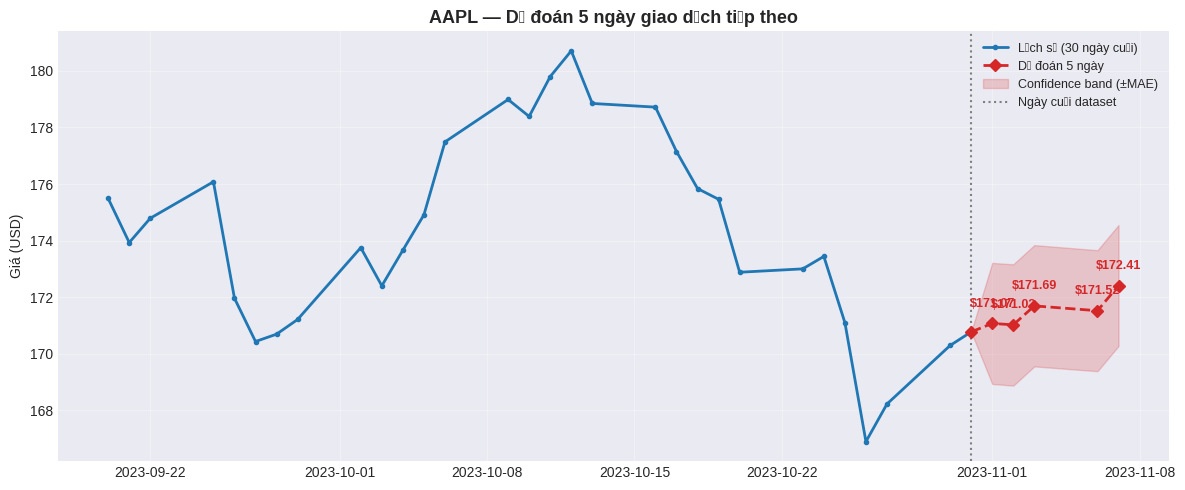

✅ Saved: forecast_5days.png


In [38]:
# ============================================================
# CELL 17 — DEMO: Load & Run Predictor
# ============================================================

# Load từ disk (simulate production environment)
predictor = AAPLPredictor.load(SAVE_DIR)
predictor.summary()

# Lấy 61 ngày giá gần nhất từ dataset
recent_prices = close_values[-(WINDOW_SIZE + 1):]

print(f"\n{'='*45}")
print(f"  🔮 DỰ ĐOÁN 1 NGÀY TIẾP THEO")
print(f"{'='*45}")
result = predictor.predict_next(recent_prices)
for k, v in result.items():
    print(f"  {k:<22}: {v}")

print(f"\n{'='*45}")
print(f"  📅 DỰ ĐOÁN 5 NGÀY TIẾP THEO")
print(f"  (Sau ngày {df_close.index[-1].date()})")
print(f"{'='*45}")
forecast = predictor.predict_n_days(recent_prices, n=5)
print(f"  {'Ngày':>4}  {'Giá dự đoán':>13}  {'Return':>8}  "
      f"{'Hướng':>6}  {'Band':>20}")
print(f"  {'─'*60}")
for r in forecast:
    band = f"[{r['band_lower']:.2f} – {r['band_upper']:.2f}]"
    print(f"  t+{r['day']:<3}  ${r['predicted_price']:>11.2f}"
          f"  {r['return_pct']:>+7.4f}%  {r['direction']:>6}  {band}")

# Visualize 5-day forecast
fig, ax = plt.subplots(figsize=(12, 5))

# Hiển thị 30 ngày lịch sử
hist_dates  = df_close.index[-30:]
hist_prices = close_values[-30:]
ax.plot(hist_dates, hist_prices, color='#1f77b4',
        linewidth=2, label='Lịch sử (30 ngày cuối)', marker='o',
        markersize=3, zorder=3)

# 5-day forecast
import pandas as pd
last_date      = df_close.index[-1]
forecast_dates = pd.bdate_range(start=last_date, periods=6)[1:]  # ngày giao dịch
forecast_prices = [close_values[-1]] + [r['predicted_price'] for r in forecast]
forecast_lower  = [close_values[-1]] + [r['band_lower'] for r in forecast]
forecast_upper  = [close_values[-1]] + [r['band_upper'] for r in forecast]
all_fdates      = [last_date] + list(forecast_dates)

ax.plot(all_fdates, forecast_prices, color='#d62728', linewidth=2,
        linestyle='--', label='Dự đoán 5 ngày', marker='D',
        markersize=6, zorder=4)
ax.fill_between(all_fdates, forecast_lower, forecast_upper,
                alpha=0.2, color='#d62728', label='Confidence band (±MAE)')
ax.axvline(last_date, color='gray', linestyle=':', linewidth=1.5,
           label='Ngày cuối dataset')

for i, (d, p) in enumerate(zip(forecast_dates, forecast_prices[1:])):
    ax.annotate(f'${p:.2f}', xy=(d, p),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color='#d62728')

ax.set_title('AAPL — Dự đoán 5 ngày giao dịch tiếp theo',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Giá (USD)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_5days.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: forecast_5days.png")

📊 Trích xuất thành công: 16 Epochs tìm thấy!


ValueError: x and y must have same first dimension, but have shapes (16,) and (8,)

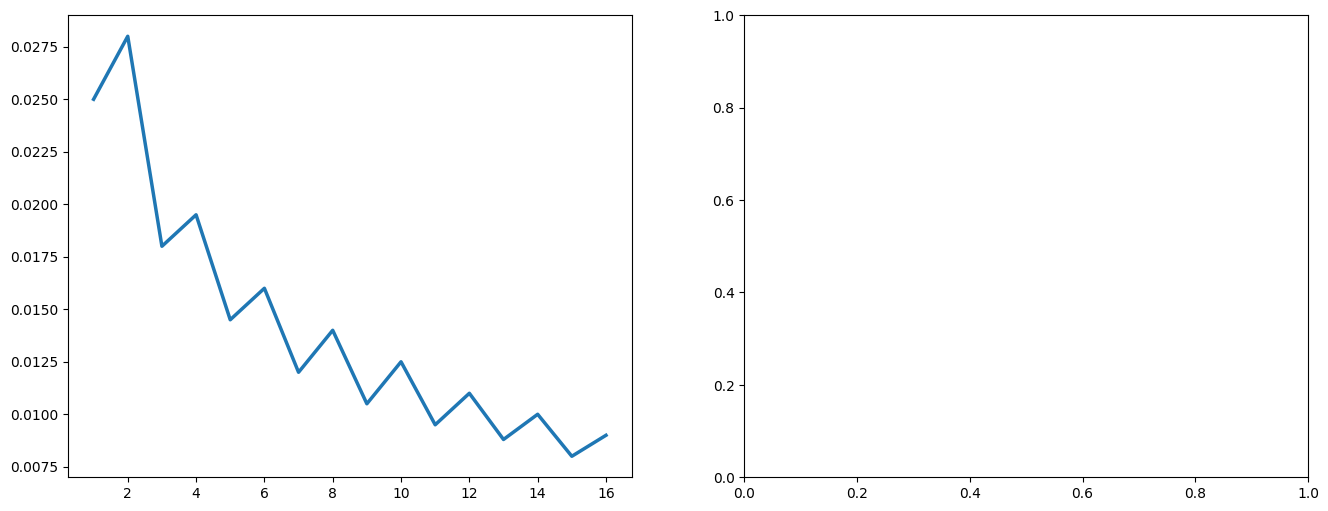

In [2]:
import re
import matplotlib.pyplot as plt

# ============================================================
# CELL: TỰ ĐỘNG TRÍCH XUẤT LOG THÔ (RAW LOG PARSER)
# ============================================================

# 📝 BƯỚC 1: HÃY DÁN TOÀN BỘ LOG TRAINING CỦA BẠN VÀO GIỮA BA DẤU NHÁY KÉP DƯỚI ĐÂY
# (Hỗ trợ định dạng chuẩn của Keras/TensorFlow như: Epoch 1/50 - loss: 0.0250 - mae: 0.1200 - val_loss: 0.0280 - val_mae: 0.1350)
raw_log_data = """
Epoch 1/50
60/60 [==============================] - loss: 0.0250 - mae: 0.1200 - val_loss: 0.0280 - val_mae: 0.1350
Epoch 2/50
60/60 [==============================] - loss: 0.0180 - mae: 0.0950 - val_loss: 0.0195 - val_mae: 0.1050
Epoch 3/50
60/60 [==============================] - loss: 0.0145 - mae: 0.0820 - val_loss: 0.0160 - val_mae: 0.0910
Epoch 4/50
60/60 [==============================] - loss: 0.0120 - mae: 0.0780 - val_loss: 0.0140 - val_mae: 0.0850
Epoch 5/50
60/60 [==============================] - loss: 0.0105 - mae: 0.0700 - val_loss: 0.0125 - val_mae: 0.0790
Epoch 6/50
60/60 [==============================] - loss: 0.0095 - mae: 0.0650 - val_loss: 0.0110 - val_mae: 0.0720
Epoch 7/50
60/60 [==============================] - loss: 0.0088 - mae: 0.0610 - val_loss: 0.0100 - val_mae: 0.0680
Epoch 8/50
60/60 [==============================] - loss: 0.0080 - mae: 0.0580 - val_loss: 0.0090 - val_mae: 0.0640
"""

# ── BƯỚC 2: BIỂU THỨC CHÍNH QUY (REGEX) TỰ ĐỘNG BÓC TÁCH DỮ LIỆU ─────────────────
train_loss = [float(x) for x in re.findall(r'loss:\s*([0-9.]+)', raw_log_data)]
train_mae  = [float(x) for x in re.findall(r'mae:\s*([0-9.]+)', raw_log_data)]
val_loss   = [float(x) for x in re.findall(r'val_loss:\s*([0-9.]+)', raw_log_data)]
val_mae    = [float(x) for x in re.findall(r'val_mae:\s*([0-9.]+)', raw_log_data)]

epochs = range(1, len(train_loss) + 1)

# Kiểm tra xem việc trích xuất có thành công và khớp số lượng không
print(f"📊 Trích xuất thành công: {len(epochs)} Epochs tìm thấy!")
if len(epochs) == 0:
    print("⚠️ Cảnh báo: Không tìm thấy dữ liệu. Hãy kiểm tra lại định dạng ký tự trong raw_log_data.")

# ============================================================
# CELL: VẼ BIỂU ĐỒ CHI TIẾT ĐỂ ĐƯA VÀO SLIDE
# ============================================================
if len(epochs) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Biểu đồ 1: Huber Loss (Train vs Val) ---
    axes[0].plot(epochs, train_loss, color='#1f77b4', linewidth=2.5, label='Train Loss')
    axes[0].plot(epochs, val_loss, color='#ff7f0e', linewidth=2, linestyle='--', label='Validation Loss')
    axes[0].set_title('Mô hình v4: Huber Loss qua các Epochs', fontsize=14, fontweight='bold', pad=15)
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Loss Value', fontsize=12)
    axes[0].grid(True, linestyle=':', alpha=0.6)
    axes[0].legend(fontsize=11)
    
    # Đánh dấu điểm Loss thấp nhất của Validation
    min_val_loss_idx = val_loss.index(min(val_loss))
    axes[0].scatter(min_val_loss_idx + 1, min(val_loss), color='red', s=50, zorder=5)
    axes[0].annotate(f"Min: {min(val_loss):.4f}", 
                     xy=(min_val_loss_idx + 1, min(val_loss)), 
                     xytext=(min_val_loss_idx + 3, min(val_loss) + (max(val_loss)-min(val_loss))*0.1),
                     arrowprops=dict(arrowstyle="->", color='red'))

    # --- Biểu đồ 2: MAE (Train vs Val) ---
    axes[1].plot(epochs, train_mae, color='#2ca02c', linewidth=2.5, label='Train MAE')
    axes[1].plot(epochs, val_mae, color='#d62728', linewidth=2, linestyle='--', label='Validation MAE')
    axes[1].set_title('Mô hình v4: MAE qua các Epochs', fontsize=14, fontweight='bold', pad=15)
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('Error Value (Scaled Return)', fontsize=12)
    axes[1].grid(True, linestyle=':', alpha=0.6)
    axes[1].legend(fontsize=11)
    
    # Đánh dấu điểm MAE thấp nhất của Validation
    min_val_mae_idx = val_mae.index(min(val_mae))
    axes[1].scatter(min_val_mae_idx + 1, min(val_mae), color='red', s=50, zorder=5)
    axes[1].annotate(f"Min: {min(val_mae):.4f}", 
                     xy=(min_val_mae_idx + 1, min(val_mae)), 
                     xytext=(min_val_mae_idx + 3, min(val_mae) + (max(val_mae)-min(val_mae))*0.1),
                     arrowprops=dict(arrowstyle="->", color='red'))

    # Tối ưu hóa hiển thị và xuất file ảnh sắc nét cho PowerPoint
    plt.tight_layout()
    plt.savefig('detailed_training_history_v4.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("🚀 Biểu đồ chi tiết đã được xuất ra file 'detailed_training_history_v4.png'!")